In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('../dados/raw/dados_originais/t3939_ppm_efetivo_rebanhos_2003_2024_ce_br.csv', sep=';', encoding='utf-8-sig')
print('shape:', df.shape)
df.head()


shape: (20460, 12)


,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,tipo_rebanho_codigo,tipo_rebanho_nome,valor
0,N1,Brasil,1,Brasil,2003,2003,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,195551576
1,N1,Brasil,1,Brasil,2004,2004,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,204512737
2,N1,Brasil,1,Brasil,2005,2005,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,207156696
3,N1,Brasil,1,Brasil,2006,2006,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,205886244
4,N1,Brasil,1,Brasil,2007,2007,105,Efetivo dos rebanhos,Cabeças,2670,Bovino,199752014


In [2]:
print('DTYPES:')
print(df.dtypes)
print()
print('NULOS (NaN nativo) por coluna:')
print(df.isna().sum())
print()
print('DUPLICATAS:', df.duplicated().sum())


DTYPES:
nivel_territorial_codigo    object
nivel_territorial_nome      object
territorio_codigo            int64
territorio_nome             object
ano_codigo                   int64
ano_nome                     int64
variavel_codigo              int64
variavel_nome               object
unidade                     object
tipo_rebanho_codigo          int64
tipo_rebanho_nome           object
valor                       object
dtype: object

NULOS (NaN nativo) por coluna:
nivel_territorial_codigo    0
nivel_territorial_nome      0
territorio_codigo           0
territorio_nome             0
ano_codigo                  0
ano_nome                    0
variavel_codigo             0
variavel_nome               0
unidade                     0
tipo_rebanho_codigo         0
tipo_rebanho_nome           0
valor                       0
dtype: int64

DUPLICATAS: 0


In [3]:
for c in df.columns:
    n = df[c].nunique()
    print(f'{c} ({n} únicos)')
    if n <= 22:
        print(df[c].value_counts().to_string())
    print()


nivel_territorial_codigo (3 únicos)
nivel_territorial_codigo
N6    20240
N1      110
N3      110

nivel_territorial_nome (3 únicos)
nivel_territorial_nome
Município               20240
Brasil                    110
Unidade da Federação      110

territorio_codigo (186 únicos)

territorio_nome (186 únicos)

ano_codigo (22 únicos)
ano_codigo
2003    930
2004    930
2005    930
2006    930
2007    930
2008    930
2009    930
2010    930
2011    930
2012    930
2013    930
2014    930
2015    930
2016    930
2017    930
2018    930
2019    930
2020    930
2021    930
2022    930
2023    930
2024    930

ano_nome (22 únicos)
ano_nome
2003    930
2004    930
2005    930
2006    930
2007    930
2008    930
2009    930
2010    930
2011    930
2012    930
2013    930
2014    930
2015    930
2016    930
2017    930
2018    930
2019    930
2020    930
2021    930
2022    930
2023    930
2024    930

variavel_codigo (1 únicos)
variavel_codigo
105    20460

variavel_nome (1 únicos)
variavel_nome
Ef

In [4]:
# coluna 'valor' vem como object -> aqui o IBGE usa "-" como marcador (não "..." como no PIB/PAM)
mask_na = pd.to_numeric(df['valor'], errors='coerce').isna()
print('linhas não numéricas:', mask_na.sum(), f"({mask_na.sum()/len(df)*100:.2f}%)")
print()
sub = df[mask_na]
print(sub['valor'].value_counts())
print()
print(sub[['nivel_territorial_nome', 'tipo_rebanho_nome', 'ano_nome']].value_counts())


linhas não numéricas: 5 (0.02%)

valor
-    5
Name: count, dtype: int64

nivel_territorial_nome  tipo_rebanho_nome  ano_nome
Município               Ovino              2017        1
                                           2018        1
                                           2019        1
                                           2020        1
                                           2021        1
Name: count, dtype: int64


**Só 5 linhas (0,02%) com `"-"` — o dataset mais completo dos 3, muito abaixo do PIB (7%) e do PAM (22%). Todas em Município/Ovino/2017-2021.**


In [5]:
# IMPORTANTE: no padrão IBGE/SIDRA, "-" significa ZERO EXATO (não "sem informação"
# como o "..." do PIB/PAM). Tratamento correto aqui é fillna(0), não deixar como NaN.
df['valor'] = pd.to_numeric(df['valor'], errors='coerce').fillna(0)
print(df.dtypes['valor'])
print('NaN restante:', df['valor'].isna().sum())


float64
NaN restante: 0


**Tratamento diferente do PIB/PAM: aqui `"-"` = zero exato (não "sem informação") → `fillna(0)`, nunca deixar como NaN.**


In [6]:
# schema check: ano_codigo == ano_nome? cobertura completa território x ano x tipo_rebanho?
print('ano_codigo == ano_nome em todas as linhas:', (df['ano_codigo'] == df['ano_nome']).all())
print()

esperado = df['territorio_codigo'].nunique() * df['ano_nome'].nunique() * df['tipo_rebanho_nome'].nunique()
print('linhas esperadas (território x ano x tipo_rebanho):', esperado)
print('linhas reais:', len(df))
print()

# padrão do nome
mun = df[df['nivel_territorial_nome'] == 'Município']
sem_sufixo = mun[~mun['territorio_nome'].str.endswith(' - CE')]['territorio_nome'].unique()
print('municípios sem sufixo " - CE":', sem_sufixo)
print()

# mapeamento código <-> nome
mapa_variavel = df.groupby('variavel_codigo')['variavel_nome'].nunique()
mapa_rebanho = df.groupby('tipo_rebanho_codigo')['tipo_rebanho_nome'].nunique()
print('variavel_codigo -> variavel_nome sempre 1:1:', (mapa_variavel == 1).all())
print('tipo_rebanho_codigo -> tipo_rebanho_nome sempre 1:1:', (mapa_rebanho == 1).all())


ano_codigo == ano_nome em todas as linhas: True

linhas esperadas (território x ano x tipo_rebanho): 20460
linhas reais: 20460

municípios sem sufixo " - CE": []

variavel_codigo -> variavel_nome sempre 1:1: True
tipo_rebanho_codigo -> tipo_rebanho_nome sempre 1:1: True


**Schema 100% consistente: 20.460 linhas batem exato (186 territórios × 22 anos × 5 rebanhos), `ano_codigo == ano_nome` sempre, mapeamento código↔nome 1:1 confirmado.**


In [7]:
# outliers via IQR por tipo de rebanho, só município (escalas muito diferentes entre espécies)
mun = df[df['nivel_territorial_nome'] == 'Município']

for reb in mun['tipo_rebanho_nome'].unique():
    sub = mun[mun['tipo_rebanho_nome'] == reb]['valor'].dropna()
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = sub[(sub < limite_inf) | (sub > limite_sup)]
    print(f'{reb}: {len(outliers)} outliers de {len(sub)} ({len(outliers)/len(sub)*100:.1f}%)')


Bovino: 321 outliers de 4048 (7.9%)
Caprino: 424 outliers de 4048 (10.5%)
Ovino: 376 outliers de 4048 (9.3%)
Suíno - total: 314 outliers de 4048 (7.8%)
Galináceos - total: 519 outliers de 4048 (12.8%)


**Outliers na mesma faixa do PIB (7,8% a 12,8%) — município com rebanho muito acima da mediana é o padrão, não a exceção rara.**


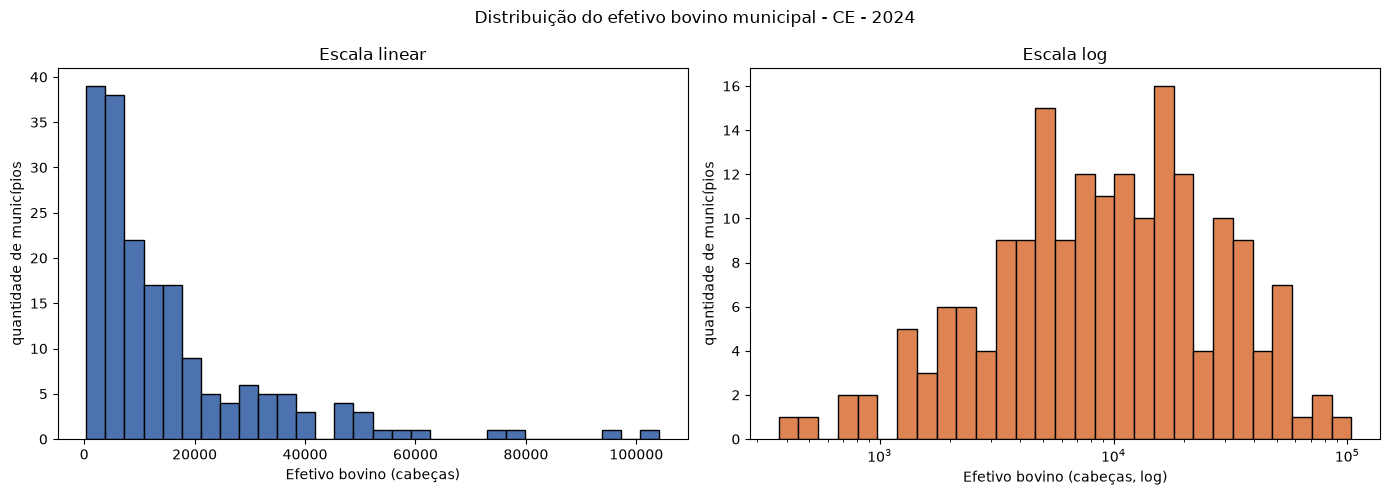

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# distribuição: efetivo bovino municipal, ano mais recente
ano_recente = df['ano_nome'].max()
bovino = mun[(mun['tipo_rebanho_nome'] == 'Bovino') & (mun['ano_nome'] == ano_recente)]['valor']
bovino = bovino[bovino > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(bovino, bins=30, color='#4c72b0', edgecolor='black')
axes[0].set_xlabel('Efetivo bovino (cabeças)')
axes[0].set_ylabel('quantidade de municípios')
axes[0].set_title('Escala linear')

axes[1].hist(bovino, bins=np.logspace(np.log10(bovino.min()), np.log10(bovino.max()), 30),
             color='#dd8452', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_xlabel('Efetivo bovino (cabeças, log)')
axes[1].set_ylabel('quantidade de municípios')
axes[1].set_title('Escala log')

fig.suptitle(f'Distribuição do efetivo bovino municipal - CE - {ano_recente}')
plt.tight_layout()
plt.show()


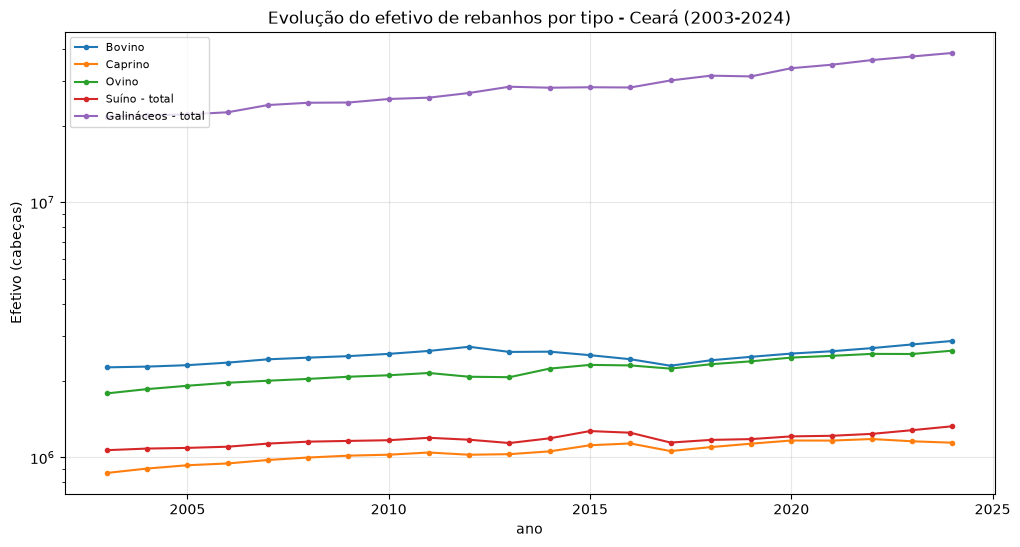

In [9]:
# evolução do efetivo por tipo de rebanho, Ceará (2003-2024)
ce = df[df['territorio_nome'] == 'Ceará'].sort_values('ano_nome')

fig, ax = plt.subplots(figsize=(12, 6))
for reb in ce['tipo_rebanho_nome'].unique():
    s = ce[ce['tipo_rebanho_nome'] == reb]
    ax.plot(s['ano_nome'], s['valor'], marker='.', label=reb)

ax.set_xlabel('ano')
ax.set_ylabel('Efetivo (cabeças)')
ax.set_title('Evolução do efetivo de rebanhos por tipo - Ceará (2003-2024)')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
plt.show()


In [10]:
# chave de junção com PIB e PAM: territorio_codigo bate? intervalo de anos bate?
pib = pd.read_csv('../dados/raw/dados_originais/t5938_pib_agropecuaria_2003_2023_ce_br.csv', sep=';', encoding='utf-8-sig')
pam = pd.read_csv('../dados/raw/dados_originais/t5457_pam_area_colhida_2003_2024_ce_br.csv', sep=';', encoding='utf-8-sig')

print('PPM territorio_codigo == PIB territorio_codigo:', set(df['territorio_codigo']) == set(pib['territorio_codigo']))
print('PPM territorio_codigo == PAM territorio_codigo:', set(df['territorio_codigo']) == set(pam['territorio_codigo']))
print()
print('PPM ano:', df['ano_nome'].min(), '-', df['ano_nome'].max())
print('PAM ano:', pam['ano_nome'].min(), '-', pam['ano_nome'].max())
print('PIB ano:', pib['ano_nome'].min(), '-', pib['ano_nome'].max())
print('atenção: PPM e PAM têm 2024, PIB não — cortar pro intervalo comum (2003-2023) antes de merge')


PPM territorio_codigo == PIB territorio_codigo: True
PPM territorio_codigo == PAM territorio_codigo: True

PPM ano: 2003 - 2024
PAM ano: 2003 - 2024
PIB ano: 2003 - 2023
atenção: PPM e PAM têm 2024, PIB não — cortar pro intervalo comum (2003-2023) antes de merge


**`territorio_codigo` bate 100% com PIB e PAM (186=186). Mesma ressalva do PAM: PPM vai até 2024, PIB só até 2023 — cortar pro intervalo comum antes de merge.**
